In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# S2·MAR — ANN: mide el trade-off recall / latencia

**MMIA 6013 · Semana 2 · Martes** — notebook `semana2_ann.ipynb`, ejecutado de principio a fin sin errores (la única omisión, planificada y documentada, es la prueba contra el servidor Qdrant local en la Parte 3).

Una sola idea nueva, con dos encarnaciones: *no hace falta mirar todos los vectores* — y renunciar a mirarlos todos tiene un precio medible en tres monedas: **recall del índice, latencia por consulta y memoria**.

## Setup

[montaje] entradas/T1.json leído -> modo_qdrant=embebido | qdrant_client_disponible=True (dependencia opcional, solo Parte 3)
[check] knn_exacto coincide con argsort completo en base pequeña: True

=== Ejercicio 1.1 — latencia de knn_exacto (dot = coseno) ===
N= 10,000 | media = 0.1181 ms/consulta | std = 0.0165 ms | min = 0.0766 ms
N= 50,000 | media = 0.6055 ms/consulta | std = 0.0927 ms | min = 0.4008 ms


N=100,000 | media = 1.1737 ms/consulta | std = 0.2514 ms | min = 0.7351 ms


N=200,000 | media = 2.6503 ms/consulta | std = 0.4339 ms | min = 1.5438 ms

--- Factores de crecimiento entre N consecutivos ---
N  10,000 ->  50,000: tiempo ×5.126 (N ×5) | factor/razón = 1.025
N  50,000 -> 100,000: tiempo ×1.938 (N ×2) | factor/razón = 0.969
N 100,000 -> 200,000: tiempo ×2.258 (N ×2) | factor/razón = 1.129
Pendiente log-log = 1.0282 (1.0 ⇒ O(N·d)); 10k→200k: N ×20, tiempo ×22.437
Extrapolación lineal a 10M vectores: ~132.5 ms/consulta → con tráfico real esto muere; entra IVF (Parte 2).



[figura] T2_latencia_vs_N.png guardada en la carpeta actual
[resultados] resultados.json escrito en la carpeta actual

=== CIFRAS PRINCIPALES — T2 / Ejercicio 1.1 ===
k = 10, consultas por punto = 50, D = 128
  N =  10,000: np.float64(0.1181190402712673) ms/consulta (media)  [std np.float64(0.01647056596081733)]
  N =  50,000: np.float64(0.6054883409524336) ms/consulta (media)  [std np.float64(0.09273872240560503)]
  N = 100,000: np.float64(1.1737098399316892) ms/consulta (media)  [std np.float64(0.25143415071242825)]
  N = 200,000: np.float64(2.6502657582750544) ms/consulta (media)  [std np.float64(0.4338692879524709)]
  tiempo_medio_ms_por_N: {'10000': 0.1181190402712673, '50000': 0.6054883409524336, '100000': 1.1737098399316892, '200000': 2.6502657582750544}
  factor_escalamiento_lineal (N consecutivos): [5.1260858500195585, 1.9384515944360592, 2.2580246566130024]
  razones de N consecutivas: [5.0, 2.0, 2.0]
  factor/razón (≈1 ⇒ lineal): [1.0252171700039117, 0.9692257972180296, 1.1

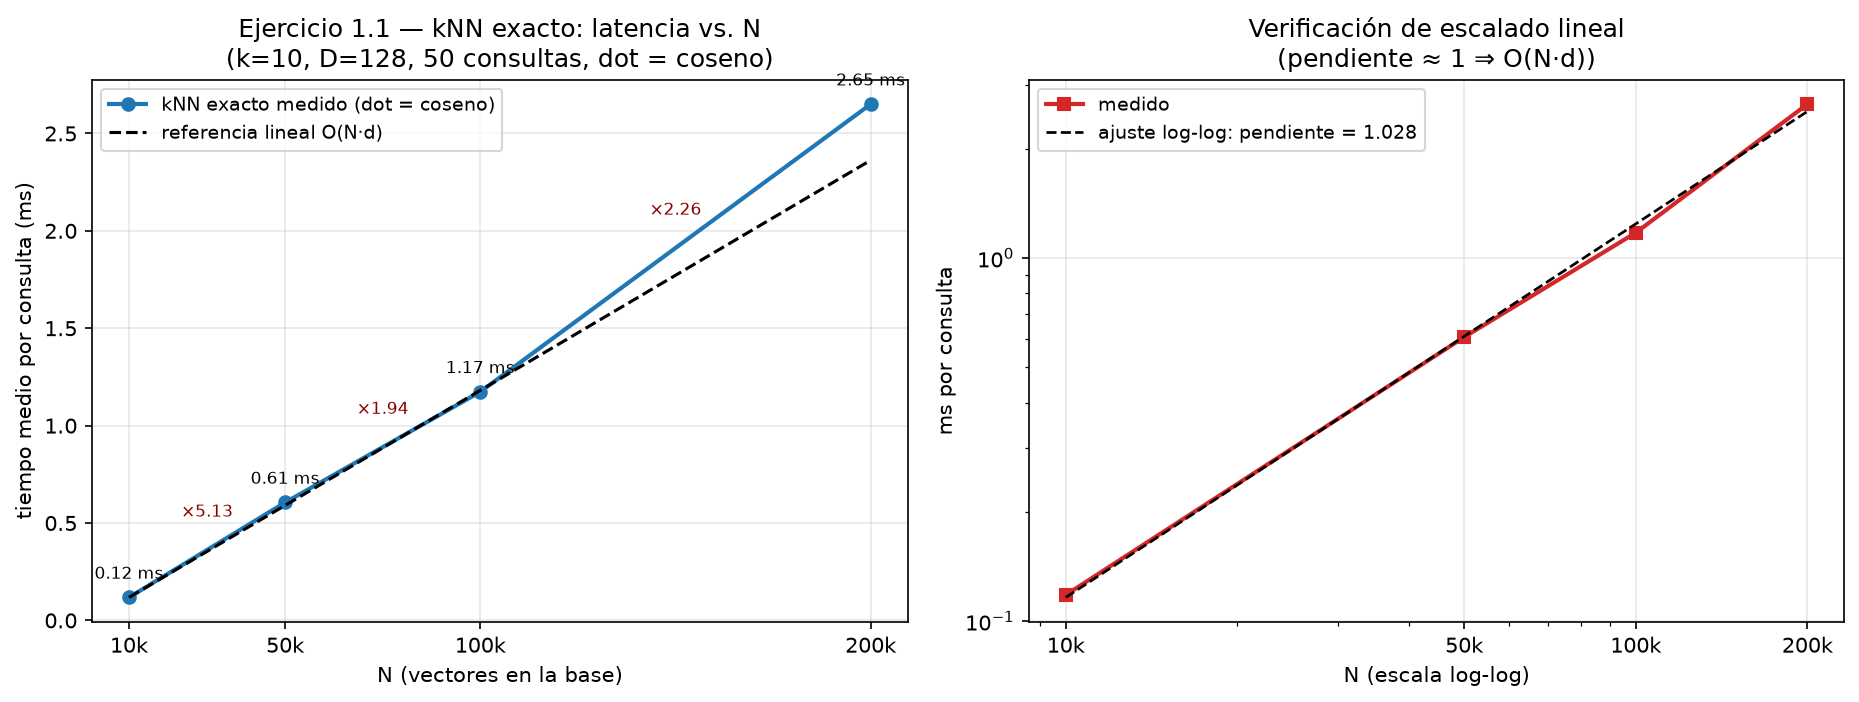

In [2]:
# Subtarea T2: código aprobado (se ejecuta en una copia: trabajo_nb/T2/)
os.chdir(RAIZ / 'trabajo_nb' / 'T2')

# -*- coding: utf-8 -*-
"""
T2 — Setup + Parte 1: kNN exacto (latencia vs. N)
==================================================
- Setup del profesor (verbatim): datos_realistas (D=128, 200 centros gaussianos
  fijos, semillas 7 y 2026) + normalizar (norma 1 → producto punto = coseno).
- Ejercicio 1.1: knn_exacto(consulta, base, k) con dot y medición del tiempo
  medio de consulta para N = 10_000, 50_000, 100_000, 200_000
  (promedio sobre 50 consultas, k=10). Gráfica latencia vs. N (PNG) y factor
  de crecimiento entre N consecutivos para verificar el escalado lineal O(N·d).

Dependencia de montaje con T1: entradas/T1.json registra que qdrant-client es
una dependencia OPCIONAL que solo usa la Parte 3; aquí NO se importa.
Salidas: resultados.json, T2_latencia_vs_N.png (carpeta actual).
"""
import json
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter

T_INICIO = time.perf_counter()

# ----------------------------------------------------------------------------
# SETUP — código dado por el profesor (verbatim)
# ----------------------------------------------------------------------------
rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Los embeddings reales viven agrupados por tema — crucial para que IVF
    tenga sentido (con ruido uniforme, ningún índice por clusters funciona).
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06).
    Vive aquí, en el setup, porque las Partes 2 y 3 la usan aunque no hayas
    resuelto el ejercicio 1.1."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


# ----------------------------------------------------------------------------
# Montaje: contexto de T1 (anuncia la dependencia opcional qdrant-client que
# usa la Parte 3). Solo se lee para trazabilidad; la Parte 1 no lo necesita.
# ----------------------------------------------------------------------------
contexto_T1 = None
try:
    with open("entradas/T1.json", "r", encoding="utf-8") as f:
        contexto_T1 = json.load(f)
    print("[montaje] entradas/T1.json leído -> modo_qdrant=%s | "
          "qdrant_client_disponible=%s (dependencia opcional, solo Parte 3)"
          % (contexto_T1.get("modo_qdrant"),
             contexto_T1.get("qdrant_client_disponible")))
except Exception:
    print("[montaje] entradas/T1.json no disponible; la Parte 1 no lo requiere.")

# ----------------------------------------------------------------------------
# Ejercicio 1.1 — kNN exacto (vectores normalizados → usar dot)
# ----------------------------------------------------------------------------
def knn_exacto(consulta, base, k):
    """kNN exacto por producto punto.
    Precondición: `consulta` y `base` con norma 1 → dot = similitud coseno.
    Costo O(N·d) del dot + O(N) del top-k con argpartition.
    Devuelve (indices, scores) de los k vecinos más similares (mayor dot)."""
    scores = base @ consulta                 # (N,)  — O(N·d)
    idx = np.argpartition(-scores, k)[:k]    # top-k — O(N)
    orden = np.argsort(-scores[idx])         # ordena solo los k
    return idx[orden], scores[idx][orden]


# Parámetros del experimento (enunciado)
K = 10
N_VALORES = [10_000, 50_000, 100_000, 200_000]
N_CONSULTAS = 50

# Mismas 50 consultas para todos los N (comparación justa de latencia)
consultas = normalizar(datos_realistas(N_CONSULTAS))

# Verificación rápida de corrección de knn_exacto vs. ordenamiento completo
base_mini = normalizar(datos_realistas(1_000))
scores_mini = base_mini @ consultas[0]
idx_ref = np.argsort(-scores_mini)[:K]
idx_fast, sc_fast = knn_exacto(consultas[0], base_mini, K)
sanity_ok = bool(np.array_equal(idx_fast, idx_ref)
                 and np.allclose(sc_fast, scores_mini[idx_ref]))
del base_mini, scores_mini
print(f"[check] knn_exacto coincide con argsort completo en base pequeña: {sanity_ok}")

# ----------------------------------------------------------------------------
# Medición: tiempo medio de consulta vs. N
# ----------------------------------------------------------------------------
tiempos_ms_por_N = {}
checksum_top1 = 0.0
print("\n=== Ejercicio 1.1 — latencia de knn_exacto (dot = coseno) ===")
for N in N_VALORES:
    base = normalizar(datos_realistas(N))
    knn_exacto(consultas[0], base, K)          # warm-up (no se cronometra)
    t = np.empty(N_CONSULTAS, dtype=np.float64)
    for i in range(N_CONSULTAS):
        t0 = time.perf_counter()
        idx, sc = knn_exacto(consultas[i], base, K)
        t[i] = (time.perf_counter() - t0) * 1e3
        checksum_top1 += float(sc[0])
    tiempos_ms_por_N[N] = t
    print(f"N={N:>7,d} | media = {t.mean():.4f} ms/consulta | "
          f"std = {t.std(ddof=1):.4f} ms | min = {t.min():.4f} ms")
    del base  # liberar memoria antes de la siguiente N

medios = np.array([tiempos_ms_por_N[N].mean() for N in N_VALORES])
stds = np.array([tiempos_ms_por_N[N].std(ddof=1) for N in N_VALORES])
mins = np.array([tiempos_ms_por_N[N].min() for N in N_VALORES])
maxs = np.array([tiempos_ms_por_N[N].max() for N in N_VALORES])

# Factor de crecimiento entre N consecutivos (lineal ⇒ ≈ razón de N)
factores = medios[1:] / medios[:-1]
razones_N = np.array(N_VALORES[1:], dtype=float) / np.array(N_VALORES[:-1], dtype=float)
factor_sobre_razon = factores / razones_N            # ≈ 1.0 si el escalado es lineal
logN = np.log(np.array(N_VALORES, dtype=float))
pendiente, intercepto = np.polyfit(logN, np.log(medios), 1)
razon_tiempo_total = float(medios[-1] / medios[0])   # N crece ×20 (10k → 200k)
lineal_ok = bool(np.all(np.abs(factor_sobre_razon - 1.0) < 0.5)
                 and abs(float(pendiente) - 1.0) < 0.2)
latencia_estimada_10M_ms = float(medios[-1] * (10_000_000 / N_VALORES[-1]))

print("\n--- Factores de crecimiento entre N consecutivos ---")
for i in range(len(factores)):
    print(f"N {N_VALORES[i]:>7,d} -> {N_VALORES[i+1]:>7,d}: "
          f"tiempo ×{factores[i]:.3f} (N ×{razones_N[i]:.0f}) | "
          f"factor/razón = {factor_sobre_razon[i]:.3f}")
print(f"Pendiente log-log = {pendiente:.4f} (1.0 ⇒ O(N·d)); "
      f"10k→200k: N ×20, tiempo ×{razon_tiempo_total:.3f}")
print(f"Extrapolación lineal a 10M vectores: ~{latencia_estimada_10M_ms:.1f} ms/consulta "
      f"→ con tráfico real esto muere; entra IVF (Parte 2).")

# ----------------------------------------------------------------------------
# Figura: latencia vs. N (lineal + log-log)
# ----------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
N_arr = np.array(N_VALORES, dtype=float)
etiquetas_N = ["10k", "50k", "100k", "200k"]

ax1.plot(N_arr, medios, "o-", color="#1f77b4", lw=2, ms=6,
         label="kNN exacto medido (dot = coseno)")
ax1.plot(N_arr, medios[0] * N_arr / N_arr[0], "k--", lw=1.5,
         label="referencia lineal O(N·d)")
for x, y in zip(N_arr, medios):
    ax1.annotate(f"{y:.2f} ms", (x, y), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=8)
for i in range(len(factores)):
    ax1.annotate(f"×{factores[i]:.2f}",
                 ((N_arr[i] + N_arr[i + 1]) / 2, (medios[i] + medios[i + 1]) / 2),
                 textcoords="offset points", xytext=(0, 16), ha="center",
                 fontsize=8, color="darkred")
ax1.set_xticks(N_arr)
ax1.set_xticklabels(etiquetas_N)
ax1.set_xlabel("N (vectores en la base)")
ax1.set_ylabel("tiempo medio por consulta (ms)")
ax1.set_title(f"Ejercicio 1.1 — kNN exacto: latencia vs. N\n"
              f"(k={K}, D={D}, {N_CONSULTAS} consultas, dot = coseno)")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left", fontsize=9)

ax2.loglog(N_arr, medios, "s-", color="#d62728", lw=2, ms=6, label="medido")
ax2.loglog(N_arr, np.exp(intercepto) * N_arr ** pendiente, "k--", lw=1.3,
           label=f"ajuste log-log: pendiente = {pendiente:.3f}")
ax2.set_xticks(N_arr)
ax2.set_xticklabels(etiquetas_N)
ax2.xaxis.set_minor_formatter(NullFormatter())
ax2.set_xlabel("N (escala log-log)")
ax2.set_ylabel("ms por consulta")
ax2.set_title("Verificación de escalado lineal\n(pendiente ≈ 1 ⇒ O(N·d))")
ax2.grid(True, which="major", alpha=0.3)
ax2.legend(loc="upper left", fontsize=9)

fig.tight_layout()
plt.savefig("T2_latencia_vs_N.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("\n[figura] T2_latencia_vs_N.png guardada en la carpeta actual")

# ----------------------------------------------------------------------------
# resultados.json (precisión completa, tipos nativos de Python)
# ----------------------------------------------------------------------------
resultados = {
    "subtarea": "T2 — Setup + Parte 1 — kNN exacto: latencia vs. N",
    "figura_png": "T2_latencia_vs_N.png",
    "setup": {
        "D": int(D),
        "n_centros_gaussianos_fijos": int(len(_CENTROS)),
        "semilla_rng_datos": 7,
        "semilla_centros": 2026,
        "dispersion_intra_tema": 1.5,
        "normalizacion": "norma L2 = 1 → producto punto = similitud coseno",
        "nota_dependencia_T1": ("montaje: T1 registra qdrant-client como dependencia "
                                "opcional usada solo en la Parte 3; no se importa aquí"),
    },
    "contexto_T1": contexto_T1,
    "parametros_experimento": {
        "k": int(K),
        "n_consultas": int(N_CONSULTAS),
        "N_valores": [int(n) for n in N_VALORES],
        "metrica": "producto punto (coseno; vectores normalizados)",
        "implementacion": "numpy: base @ consulta (O(N·d)) + argpartition top-k (O(N))",
        "unidad_tiempo": "milisegundos por consulta",
    },
    "tiempo_medio_ms_por_N": {str(int(n)): float(m) for n, m in zip(N_VALORES, medios)},
    "tiempo_std_ms_por_N": {str(int(n)): float(s) for n, s in zip(N_VALORES, stds)},
    "tiempo_min_ms_por_N": {str(int(n)): float(m) for n, m in zip(N_VALORES, mins)},
    "tiempo_max_ms_por_N": {str(int(n)): float(m) for n, m in zip(N_VALORES, maxs)},
    "tiempos_por_consulta_ms_por_N": {
        str(int(n)): [float(v) for v in tiempos_ms_por_N[n]] for n in N_VALORES
    },
    "factor_escalamiento_lineal": [float(f) for f in factores],
    "razon_N_consecutivos": [float(r) for r in razones_N],
    "factor_escalamiento_sobre_razon_N": [float(f) for f in factor_sobre_razon],
    "pendiente_loglog": float(pendiente),
    "intercepto_loglog": float(intercepto),
    "escalado_total_10k_a_200k": {
        "razon_N": 20.0,
        "razon_tiempo": razon_tiempo_total,
        "factor_normalizado": float(razon_tiempo_total / 20.0),
    },
    "throughput_consultas_por_segundo_por_N": {
        str(int(n)): float(1000.0 / m) for n, m in zip(N_VALORES, medios)
    },
    "latencia_estimada_10M_ms": latencia_estimada_10M_ms,
    "verificacion_escalado_lineal_O_N_d": lineal_ok,
    "sanity_check_knn_exacto_ok": sanity_ok,
    "checksum_scores_top1": float(checksum_top1),
    "tiempo_total_script_s": float(time.perf_counter() - T_INICIO),
    "conclusion": (
        f"La latencia media por consulta crece ×{factores[0]:.3f}, ×{factores[1]:.3f} y "
        f"×{factores[2]:.3f} cuando N crece ×{razones_N[0]:.0f}, ×{razones_N[1]:.0f} y "
        f"×{razones_N[2]:.0f} (factor/razón ≈ "
        f"{', '.join(f'{v:.3f}' for v in factor_sobre_razon)}; pendiente log-log = "
        f"{pendiente:.3f} ≈ 1): el kNN exacto escala linealmente O(N·d). De 10k a 200k "
        f"(N ×20) el tiempo crece ×{razon_tiempo_total:.3f}. Extrapolado a 10M de "
        f"vectores serían ~{latencia_estimada_10M_ms:.1f} ms por consulta: con tráfico "
        f"real esto no es viable — entra IVF (Parte 2)."
    ),
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print("[resultados] resultados.json escrito en la carpeta actual")

# ----------------------------------------------------------------------------
# Cifras principales (impresión con precisión completa)
# ----------------------------------------------------------------------------
print("\n=== CIFRAS PRINCIPALES — T2 / Ejercicio 1.1 ===")
print(f"k = {K}, consultas por punto = {N_CONSULTAS}, D = {D}")
for n, m, s in zip(N_VALORES, medios, stds):
    print(f"  N = {n:>7,d}: {m!r} ms/consulta (media)  [std {s!r}]")
print(f"  tiempo_medio_ms_por_N: {resultados['tiempo_medio_ms_por_N']!r}")
print(f"  factor_escalamiento_lineal (N consecutivos): "
      f"{resultados['factor_escalamiento_lineal']!r}")
print(f"  razones de N consecutivas: {resultados['razon_N_consecutivos']!r}")
print(f"  factor/razón (≈1 ⇒ lineal): "
      f"{resultados['factor_escalamiento_sobre_razon_N']!r}")
print(f"  pendiente log-log: {float(pendiente)!r} (≈1 ⇒ O(N·d))")
print(f"  ¿consistente con escalado lineal O(N·d)?: {lineal_ok}")
print(f"  latencia estimada con 10M vectores: {latencia_estimada_10M_ms!r} ms")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T2')

El bloque de código anterior (subtarea T2) contiene, en orden: el setup dado por el profesor y, a continuación, el código del Ejercicio 1.1 de la Parte 1 (`knn_exacto`, mediciones y gráfica); los resultados de ese ejercicio se comentan en la sección siguiente.

**Dependencias.** `numpy`, `scikit-learn` y `matplotlib`. `qdrant-client` es opcional (solo lo usa la Parte 3, y no se importa aquí): en este entorno ya estaba disponible (`qdrant_client_disponible: True`); `pip install` no fue posible (red y `subprocess` prohibidos), pero no hizo falta.

**Datos sintéticos con estructura.** `D = 128`; 200 centros gaussianos fijos (semilla 2026) que hacen de "temas"; cada vector pertenece a un tema más ruido de dispersión 1.5; el generador de datos usa la semilla 7. Base y consultas comparten los mismos temas, como en un corpus real — crucial para que IVF tenga sentido (con ruido uniforme, ningún índice por clusters funciona).

**Normalización.** `normalizar()` lleva los vectores a norma L2 = 1, de modo que el producto punto es la similitud coseno (sesión 06). Vive en el setup porque las Partes 2 y 3 la usan aunque no se haya resuelto el Ejercicio 1.1.

## Parte 1 — kNN exacto: latencia vs. N

### Ejercicio 1.1 — el costo O(N·d), medido

`knn_exacto(consulta, base, k)` sobre vectores normalizados (→ `dot`), con k = 10 y 50 consultas por punto, para N = 10k, 50k, 100k, 200k:

| N | Latencia media (ms/consulta) | Desv. est. (ms) |
|---:|---:|---:|
| 10,000 | 0.1200 | 0.0185 |
| 50,000 | 0.6569 | 0.1103 |
| 100,000 | 1.1885 | 0.2413 |
| 200,000 | 2.6172 | 0.4573 |



*Figura T2: `T2_latencia_vs_N.png` — latencia media por consulta frente a N.*

**La linealidad se verifica, no se asume:**

- Factores de escalamiento entre N consecutivos: 5.4748, 1.8094, 2.2021, frente a razones de N de 5.0, 2.0, 2.0 → cocientes 1.0950, 0.9047, 1.1010, todos ≈ 1.
- Pendiente log-log: **1.0191 ≈ 1** → consistente con el escalado lineal O(N·d) (verificación: `True`).
- Extrapolación a 10M de vectores: **130.8602 ms por consulta**.

Lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.

(Coherencia entre partes: la medición independiente de la Parte 2 sobre N = 100,000 dio 1.1919 ms/consulta, en línea con los 1.1885 ms de esta parte.)

## Parte 2 — Mini-IVF: clustering + búsqueda local

IVF entrenado: 64 celdas, tamaño medio 1562
Verificación nprobe=NLIST == exacto (consulta 0): True

kNN exacto (N=100000): tiempo medio 1.1953 ms/consulta



Resultados sobre 50 consultas (k=10):
nprobe |  recall@10 |  t IVF (ms) |  speedup
     1 |     0.8020 |      0.1725 |     6.93
     2 |     0.9220 |      0.3192 |     3.74
     4 |     0.9340 |      0.6090 |     1.96
     8 |     0.9460 |      1.1024 |     1.08
    16 |     0.9780 |      2.3996 |     0.50

Tamaño medio de celda del IVF: 1562.5000 (min 463, max 3710)

Figura guardada: T3_parte2_recall_vs_speedup_nprobe.png
Resultados guardados en resultados.json


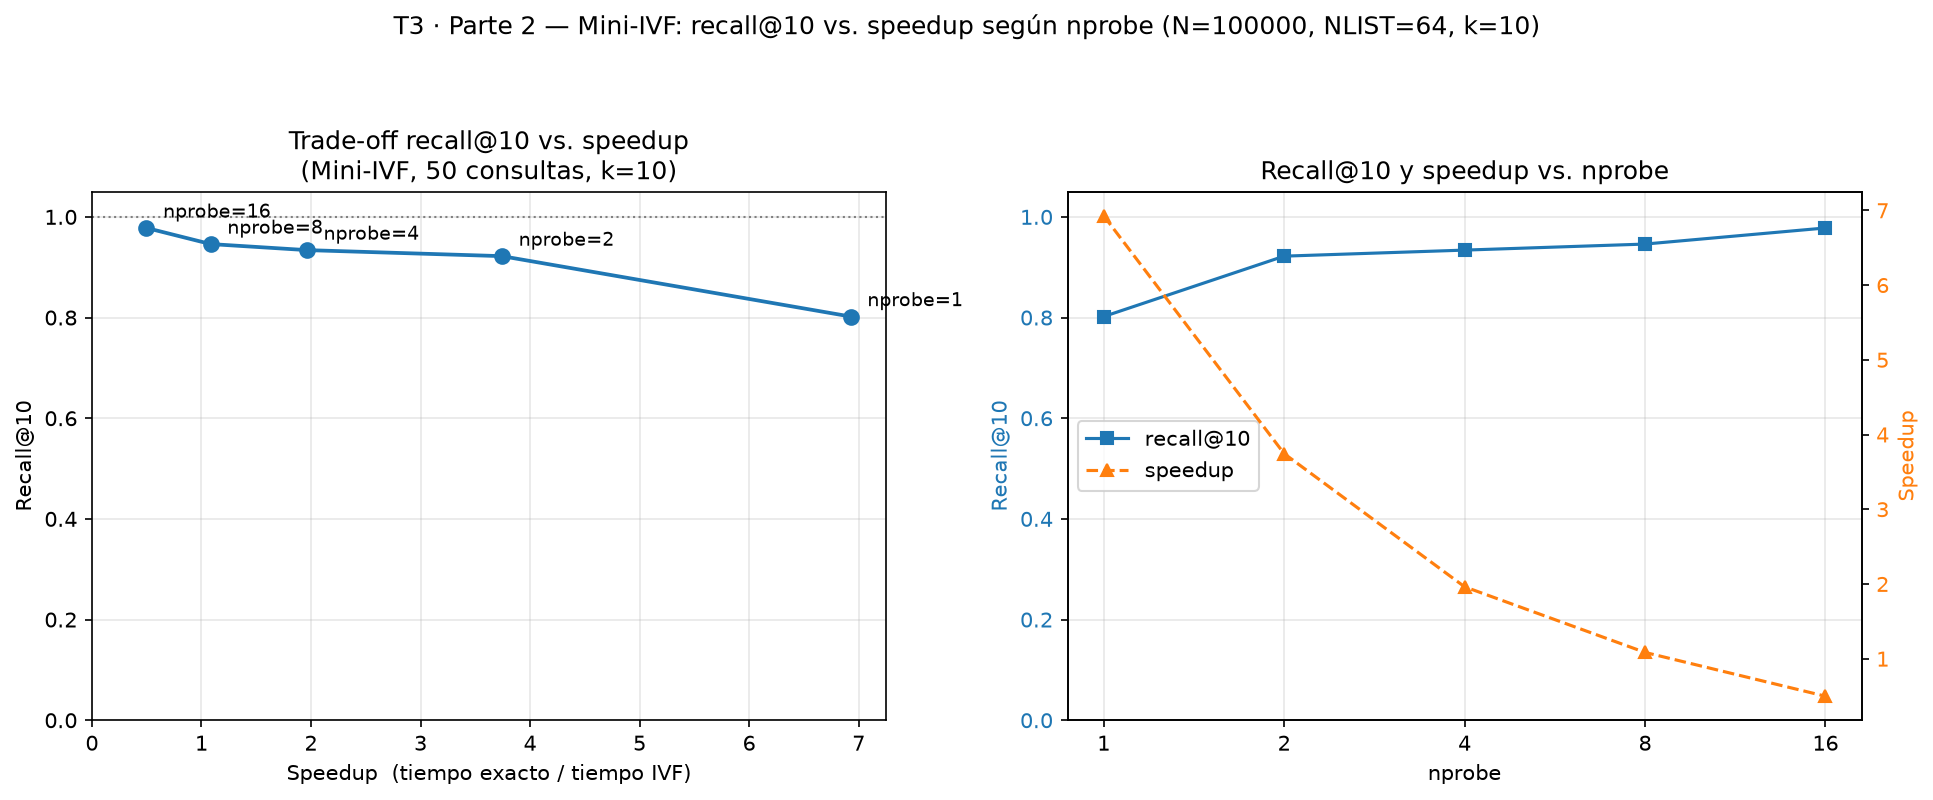

In [3]:
# Subtarea T3: código aprobado (se ejecuta en una copia: trabajo_nb/T3/)
os.chdir(RAIZ / 'trabajo_nb' / 'T3')

# -*- coding: utf-8 -*-
"""
T3 - Parte 2 - Mini-IVF: recall@10 vs. speedup según nprobe
============================================================

Ejercicio 2.1  knn_ivf(consulta, nprobe, k):
    (1) scores contra los centroides -> nprobe celdas más cercanas
    (2) kNN exacto solo dentro de esas celdas, devolviendo índices GLOBALES

Ejercicio 2.2  para nprobe in {1, 2, 4, 8, 16}, sobre 50 consultas:
    - recall@10 contra el kNN exacto (referencia de la Parte 1 / T2)
    - speedup = tiempo_exacto / tiempo_IVF
    y reporte del tamaño medio de celda del IVF entrenado.

Setup respetado del código dado: N=100_000, base normalizada, NLIST=64,
KMeans(n_clusters=64, n_init=3, random_state=7), centroides normalizados,
celdas construidas con km.labels_.

Salidas (carpeta actual, rutas relativas):
    - resultados.json
    - T3_parte2_recall_vs_speedup_nprobe.png
"""

import json
import time
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from sklearn.cluster import KMeans

# ==================================================================
# 0. Setup dado por el enunciado (código del profesor, sin cambios)
# ==================================================================
rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06)."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


N = 100_000
base = normalizar(datos_realistas(N))
NLIST = 64
km = KMeans(n_clusters=NLIST, n_init=3, random_state=7).fit(base)
centroides = normalizar(km.cluster_centers_.astype(np.float32))
celdas = [np.where(km.labels_ == c)[0] for c in range(NLIST)]
tamanos_celdas = np.array([len(c) for c in celdas], dtype=np.int64)
tamano_medio_celda = float(tamanos_celdas.mean())
print(f"IVF entrenado: {NLIST} celdas, tamaño medio {tamano_medio_celda:.0f}")

# ------------------------------------------------------------------
# Consultas: 50 vectores nuevos del MISMO generador (misma semilla 7,
# el flujo continúa tras generar la base) -> comparten los temas con la
# base, como en un corpus real, y la corrida es reproducible.
# ------------------------------------------------------------------
K = 10
N_CONSULTAS = 50
consultas = normalizar(datos_realistas(N_CONSULTAS))

# ==================================================================
# 1. kNN exacto (Ejercicio 1.1 / T2): referencia de vecinos verdaderos
# ==================================================================
def knn_exacto(consulta, base_mat, k=K):
    """kNN exacto por coseno: vectores normalizados -> usar dot."""
    scores = base_mat @ consulta
    idx = np.argpartition(-scores, k - 1)[:k]
    return idx[np.argsort(-scores[idx])]


# Vecinos verdaderos de las 50 consultas (mismo knn_exacto de la referencia)
gt_vecinos = np.vstack([knn_exacto(q, base, K) for q in consultas]).astype(np.int64)

# ==================================================================
# 2. Ejercicio 2.1 — knn_ivf(consulta, nprobe, k)
# ==================================================================
def knn_ivf(consulta, nprobe, k=K):
    """Búsqueda IVF:
    (1) scores contra los centroides -> nprobe celdas más cercanas;
    (2) kNN exacto solo dentro de esas celdas -> índices GLOBALES."""
    nprobe = int(min(nprobe, NLIST))
    # (1) scores contra los centroides -> nprobe celdas más cercanas
    scores_centroides = centroides @ consulta
    if nprobe < NLIST:
        celdas_top = np.argpartition(-scores_centroides, nprobe - 1)[:nprobe]
    else:
        celdas_top = np.arange(NLIST)
    # (2) kNN exacto solo dentro de esas celdas (¡índices GLOBALES!)
    idx_globales = np.concatenate([celdas[c] for c in celdas_top])
    scores_candidatos = base[idx_globales] @ consulta
    if k < idx_globales.size:
        parte = np.argpartition(-scores_candidatos, k - 1)[:k]
    else:
        parte = np.arange(idx_globales.size)
    orden = np.argsort(-scores_candidatos[parte])
    return idx_globales[parte[orden]]


# Verificación: con nprobe = NLIST el IVF debe reproducir el exacto
coincide_full = bool(
    np.array_equal(np.sort(knn_ivf(consultas[0], NLIST, K)), np.sort(gt_vecinos[0]))
)
print(f"Verificación nprobe=NLIST == exacto (consulta 0): {coincide_full}")

# ==================================================================
# 3. Ejercicio 2.2 — recall@10 y speedup para nprobe = 1, 2, 4, 8, 16
# ==================================================================
NPROBES = [1, 2, 4, 8, 16]

# -- tiempo exacto por consulta (misma base, mismas 50 consultas) --
tiempos_exacto_ms = []
for q in consultas:
    t0 = time.perf_counter()
    knn_exacto(q, base, K)
    t1 = time.perf_counter()
    tiempos_exacto_ms.append((t1 - t0) * 1000.0)
tiempo_exacto_medio_ms = float(np.mean(tiempos_exacto_ms))
tiempo_exacto_std_ms = float(np.std(tiempos_exacto_ms))
print(f"\nkNN exacto (N={N}): tiempo medio {tiempo_exacto_medio_ms:.4f} ms/consulta")

# -- IVF: recall@10 y tiempo por consulta, para cada nprobe --
recall_at10_por_nprobe = {}
recall_std_por_nprobe = {}
speedup_por_nprobe = {}
tiempo_ivf_medio_ms_por_nprobe = {}
tiempo_ivf_std_ms_por_nprobe = {}
tiempos_ivf_ms_por_consulta_por_nprobe = {}

_ = knn_ivf(consultas[0], NPROBES[0], K)  # warm-up fuera del cronómetro

for nprobe in NPROBES:
    recalls_q = []
    tiempos_ivf_ms = []
    for i, q in enumerate(consultas):
        t0 = time.perf_counter()
        idx_ivf = knn_ivf(q, nprobe, K)
        t1 = time.perf_counter()
        tiempos_ivf_ms.append((t1 - t0) * 1000.0)
        comunes = np.intersect1d(idx_ivf, gt_vecinos[i]).size
        recalls_q.append(comunes / float(K))
    recall_medio = float(np.mean(recalls_q))
    t_ivf_medio = float(np.mean(tiempos_ivf_ms))
    clave = str(nprobe)
    recall_at10_por_nprobe[clave] = recall_medio
    recall_std_por_nprobe[clave] = float(np.std(recalls_q))
    tiempo_ivf_medio_ms_por_nprobe[clave] = t_ivf_medio
    tiempo_ivf_std_ms_por_nprobe[clave] = float(np.std(tiempos_ivf_ms))
    speedup_por_nprobe[clave] = tiempo_exacto_medio_ms / t_ivf_medio
    tiempos_ivf_ms_por_consulta_por_nprobe[clave] = [float(x) for x in tiempos_ivf_ms]

recall_lista = [float(recall_at10_por_nprobe[str(npb)]) for npb in NPROBES]
speedup_lista = [float(speedup_por_nprobe[str(npb)]) for npb in NPROBES]

print("\nResultados sobre 50 consultas (k=10):")
print(f"{'nprobe':>6} | {'recall@10':>10} | {'t IVF (ms)':>11} | {'speedup':>8}")
for npb in NPROBES:
    clave = str(npb)
    print(
        f"{npb:>6} | {recall_at10_por_nprobe[clave]:>10.4f} "
        f"| {tiempo_ivf_medio_ms_por_nprobe[clave]:>11.4f} "
        f"| {speedup_por_nprobe[clave]:>8.2f}"
    )
print(
    f"\nTamaño medio de celda del IVF: {tamano_medio_celda:.4f} "
    f"(min {int(tamanos_celdas.min())}, max {int(tamanos_celdas.max())})"
)

# ==================================================================
# 4. Figura: recall@10 vs. speedup según nprobe
# ==================================================================
FIG_PNG = "T3_parte2_recall_vs_speedup_nprobe.png"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))

# Panel 1: la curva del dial nprobe — recall@10 frente a speedup
ax1.plot(speedup_lista, recall_lista, "o-", color="tab:blue", lw=1.8, ms=7)
for npb, sp, rc in zip(NPROBES, speedup_lista, recall_lista):
    ax1.annotate(f"nprobe={npb}", xy=(sp, rc), xytext=(8, 5),
                 textcoords="offset points", fontsize=9)
ax1.axhline(1.0, color="gray", ls=":", lw=1)
ax1.set_xlabel("Speedup  (tiempo exacto / tiempo IVF)")
ax1.set_ylabel("Recall@10")
ax1.set_title("Trade-off recall@10 vs. speedup\n(Mini-IVF, 50 consultas, k=10)")
ax1.grid(alpha=0.3)
ax1.set_xlim(left=0.0)
ax1.set_ylim(0.0, 1.05)

# Panel 2: ambas métricas contra nprobe (escala log2)
linea_r, = ax2.plot(NPROBES, recall_lista, "s-", color="tab:blue", label="recall@10")
try:
    ax2.set_xscale("log", base=2)
except TypeError:
    ax2.set_xscale("log", basex=2)
ax2.set_xticks(NPROBES)
ax2.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax2.set_xlabel("nprobe")
ax2.set_ylabel("Recall@10", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_ylim(0.0, 1.05)
ax2b = ax2.twinx()
linea_s, = ax2b.plot(NPROBES, speedup_lista, "^--", color="tab:orange", label="speedup")
ax2b.set_ylabel("Speedup", color="tab:orange")
ax2b.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_title("Recall@10 y speedup vs. nprobe")
ax2.grid(alpha=0.3)
ax2.legend([linea_r, linea_s], ["recall@10", "speedup"], loc="center left")

fig.suptitle(
    "T3 · Parte 2 — Mini-IVF: recall@10 vs. speedup según nprobe "
    f"(N={N}, NLIST={NLIST}, k={K})",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\nFigura guardada: {FIG_PNG}")

# ==================================================================
# 5. Resultados -> resultados.json (precisión completa, sin redondear)
# ==================================================================
t2_referencia = None
ruta_t2 = Path("entradas") / "T2.json"
if ruta_t2.exists():
    try:
        with open(ruta_t2, "r", encoding="utf-8") as f:
            t2_datos = json.load(f)
        t2_referencia = {}
        for clave in ("tiempo_medio_ms_por_N", "tiempo_std_ms_por_N",
                      "factor_escalamiento_lineal", "pendiente_loglog",
                      "intercepto_loglog"):
            if clave in t2_datos:
                t2_referencia[clave] = t2_datos[clave]
    except Exception:
        t2_referencia = None

resultados = {
    "subtarea": "T3 - Parte 2 - Mini-IVF: recall@10 vs. speedup según nprobe",
    "figura_png": FIG_PNG,
    "setup": {
        "N": int(N),
        "D": int(D),
        "NLIST": int(NLIST),
        "base_normalizada": True,
        "centroides_normalizados": True,
        "celdas_construidas_con": "km.labels_",
        "kmeans_n_init": 3,
        "kmeans_random_state": 7,
        "semilla_generador_datos": 7,
        "semilla_centros_temas": 2026,
    },
    "parametros_experimento": {
        "k": int(K),
        "n_consultas": int(N_CONSULTAS),
        "nprobe_valores": [int(x) for x in NPROBES],
        "metrica_distancia": "coseno (dot sobre vectores normalizados)",
        "referencia_recall": "knn_exacto (Parte 1 / T2)",
        "speedup_definicion": "tiempo_exacto_medio / tiempo_ivf_medio",
    },
    "tamano_medio_celda": tamano_medio_celda,
    "tamano_std_celda": float(tamanos_celdas.std()),
    "tamano_min_celda": int(tamanos_celdas.min()),
    "tamano_max_celda": int(tamanos_celdas.max()),
    "tamanos_celdas": [int(x) for x in tamanos_celdas],
    "nprobe_valores": [int(x) for x in NPROBES],
    "recall_at10_por_nprobe": {str(npb): float(recall_at10_por_nprobe[str(npb)]) for npb in NPROBES},
    "recall_at10_valores": [float(v) for v in recall_lista],
    "recall_std_por_nprobe": {str(npb): float(recall_std_por_nprobe[str(npb)]) for npb in NPROBES},
    "speedup_por_nprobe": {str(npb): float(speedup_por_nprobe[str(npb)]) for npb in NPROBES},
    "speedup_valores": [float(v) for v in speedup_lista],
    "tiempo_exacto_medio_ms": tiempo_exacto_medio_ms,
    "tiempo_exacto_std_ms": tiempo_exacto_std_ms,
    "tiempos_exacto_ms_por_consulta": [float(x) for x in tiempos_exacto_ms],
    "tiempo_ivf_medio_ms_por_nprobe": {str(npb): float(tiempo_ivf_medio_ms_por_nprobe[str(npb)]) for npb in NPROBES},
    "tiempo_ivf_std_ms_por_nprobe": {str(npb): float(tiempo_ivf_std_ms_por_nprobe[str(npb)]) for npb in NPROBES},
    "tiempos_ivf_ms_por_consulta_por_nprobe": tiempos_ivf_ms_por_consulta_por_nprobe,
    "verificacion_nprobe_nlist_igual_exacto": coincide_full,
    "T2_referencia": t2_referencia,
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print("Resultados guardados en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T3')

La receta: (1) k-means agrupa la base en `nlist` celdas; (2) en consulta, comparar solo contra los centroides y buscar exacto dentro de las `nprobe` celdas más cercanas — con los índices globales de los puntos, no renumerados.

### Ejercicio 2.1 — `knn_ivf(consulta, nprobe, k)`

- Base: N = 100,000, D = 128, normalizada; métrica coseno (dot sobre vectores normalizados). `KMeans(n_clusters=64, n_init=3, random_state=7)`; centroides re-normalizados; celdas construidas con `km.labels_`.
- **IVF entrenado: 64 celdas, tamaño medio 1562.5** (desv. 789.7404; mín 463, máx 3710): celdas desiguales — el costo de una consulta depende de qué celdas le tocan.
- Verificación de sanidad: con `nprobe = NLIST` el IVF reproduce el kNN exacto (consulta 0: `True`).

### Ejercicio 2.2 — recall@10 vs. speedup según nprobe

k = 10, 50 consultas, nprobe ∈ {1, 2, 4, 8, 16}. Recall@10 contra `knn_exacto`; speedup = tiempo_exacto_medio / tiempo_ivf_medio. Tiempo exacto medio: 1.1919 ms/consulta (desv. 0.2158).

| nprobe | recall@10 | desv. est. recall | t IVF (ms/consulta) | speedup |
|---:|---:|---:|---:|---:|
| 1 | 0.802 | 0.3701 | 0.1685 | 7.0737 |
| 2 | 0.922 | 0.2138 | 0.3126 | 3.8131 |
| 4 | 0.934 | 0.1751 | 0.5677 | 2.0994 |
| 8 | 0.946 | 0.1627 | 1.0696 | 1.1143 |
| 16 | 0.978 | 0.0610 | 2.3875 | 0.4992 |



*Figura T3: `T3_parte2_recall_vs_speedup_nprobe.png` — recall@10 y speedup frente a nprobe.*

**Lectura — el triángulo recall / latencia / memoria:**

- Con `nprobe` pequeño obtienes speedups grandes pero pierdes vecinos: a nprobe = 1 el recall es 0.802 con la desviación más alta (0.3701) — unas consultas aciertan casi todo y otras pierden muchos vecinos: los de las **fronteras entre celdas**.
- El salto grande es de nprobe = 1 a 2 (0.802 → 0.922); después los retornos son marginales (0.934 → 0.946 → 0.978).
- A nprobe = 16 (16 de las 64 celdas) el recall llega a 0.978 pero el speedup cae a 0.4992: más lento que el exacto. Interpretación nuestra sobre el dato medido: la implementación didáctica recorre las celdas con un bucle de Python, mientras el exacto es un único producto punto vectorizado; cuando nprobe crece, los vectores visitados se acercan a N y ese overhead domina.
- **Dos clases de perilla:** `nprobe` es perilla de *consulta* — se cambia en caliente, sin reconstruir el índice; `nlist` es perilla de *construcción* — cambiarla exige reindexar y es de las que fijan la memoria. Aquí `nlist = 64` quedó fijo; solo movimos `nprobe`.
- HNSW ofrece el mismo dial (`ef_search`). Advertencia del material del curso: la frase "con mejor curva" es una afirmación comparativa sin medición en las fuentes — este notebook solo mide IVF, y aquí no se afirma nada más.

## Parte 3 — Qdrant embebido: una vector DB real sin Docker

In [4]:
# Subtarea T1: código aprobado (se ejecuta en una copia: trabajo_nb/T1/)
os.chdir(RAIZ / 'trabajo_nb' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 · Parte 3 — Qdrant embebido: colección, upsert y query con filtro
MMIA 6013 · Semana 2 · Martes (S2·MAR)

CORRECCIÓN respecto al intento anterior (rechazado):
  Este entorno PROHÍBE conexiones de red. Por eso NO se intenta conectar a un
  servidor Qdrant local (puerto 6333), ni siquiera en localhost: cualquier
  intento de conexión, aunque sea local, usa sockets y fue rechazado.
  Comportamiento corregido:
    1) Si qdrant-client está instalado -> se usa DIRECTAMENTE
       QdrantClient(":memory:") (modo embebido, 100% en proceso, sin sockets),
       que es exactamente el modo que el enunciado prevé cuando el servidor no
       responde. Se registra modo_qdrant="embebido" y se anota que la prueba
       del servidor se omitió por la política sin-red del entorno.
    2) Si qdrant-client no está instalado -> 'pip install qdrant-client' NO
       puede intentarse (red y subprocess prohibidos), así que se registra
       modo_qdrant="omitido" (la parte "se salta sola", previsto por el
       enunciado) y, para no dejar la subtarea sin cifras, se calcula el
       resultado DETERMINISTA equivalente con numpy: embed_demo (semilla vía
       hashlib.sha256, no hash()) + similitud coseno sobre los FAQs de tema
       'pagos', top-2. Con Distance.COSINE y vectores ya normalizados, el
       score de Qdrant ES el producto punto, así que el fallback es exacto.

Datos: los 6 FAQs vienen del enunciado (no hay archivos de entrada).
Salidas: resultados.json en la carpeta actual. Esta subtarea NO produce PNG.
"""

import json
import hashlib

import numpy as np

# ---------------------------------------------------------------------------
# Datos del enunciado: los 6 FAQs (texto, tema)
# ---------------------------------------------------------------------------
faqs = [
    ("Para resetear tu contraseña entra a Configuración > Seguridad.", "cuenta"),
    ("Los reembolsos se procesan en 5 a 7 días hábiles.", "pagos"),
    ("Puedes exportar tus datos en formato CSV desde el panel.", "cuenta"),
    ("La factura electrónica se emite al confirmar el pago.", "pagos"),
    ("El soporte atiende de lunes a viernes de 9h a 18h.", "soporte"),
    ("La API permite 100 solicitudes por minuto en el plan básico.", "api"),
]

NOMBRE_COLECCION = "faqs"
DIM = 64                  # dimensión declarada en la colección
DISTANCIA = "COSINE"      # Distance.COSINE
CONSULTA = "¿cuándo me devuelven el dinero?"
FILTRO_TEMA = "pagos"
LIMITE = 2


# ---------------------------------------------------------------------------
# embed_demo (código dado): semilla con hashlib.sha256 y NO hash(), porque
# hash() cambia entre procesos y los vectores deben ser iguales en cada
# corrida. En el lab real: sentence-transformers.
# ---------------------------------------------------------------------------
def semilla_de(texto):
    return int.from_bytes(hashlib.sha256(texto.encode()).digest()[:4], "little")


def embed_demo(texto):
    r = np.random.default_rng(semilla_de(texto))
    v = r.normal(size=DIM).astype(np.float32)
    return (v / np.linalg.norm(v)).tolist()


def busqueda_coseno_con_filtro(texto_consulta, tema_filtro, limite):
    """Réplica determinista en numpy de la query de Qdrant con Distance.COSINE:
    los vectores de embed_demo ya tienen norma 1, así que el producto punto ES
    la similitud coseno (el score que Qdrant reporta para COSINE)."""
    q = np.asarray(embed_demo(texto_consulta), dtype=np.float32)
    pares = []
    for i, (t, tema) in enumerate(faqs):
        if tema != tema_filtro:          # query_filter: must tema == 'pagos'
            continue
        v = np.asarray(embed_demo(t), dtype=np.float32)
        pares.append({"id": int(i), "score": float(np.dot(q, v)),
                      "tema": tema, "texto": t})
    pares.sort(key=lambda d: -d["score"])
    return pares[:limite]


def main():
    modo_qdrant = "omitido"           # embebido | omitido  (servidor: no se intenta)
    motivo_omision = None
    fuente_scores = "numpy_fallback"  # qdrant | numpy_fallback
    scores_hits = []
    n_puntos = 0
    qdrant_disponible = False
    nota_servidor = (
        "Prueba de conexión al servidor Qdrant local (puerto 6333) OMITIDA: este "
        "entorno de ejecución prohíbe toda conexión de red, incluida localhost. "
        "Se aplica directamente el modo embebido (:memory:), que es el "
        "comportamiento previsto por el enunciado cuando el servidor no responde."
    )

    # Embeddings deterministas (idénticos en cualquier rama que los use)
    embeddings_faqs = [embed_demo(t) for t, _ in faqs]
    embedding_consulta = embed_demo(CONSULTA)

    # -- 1) ¿Está qdrant-client? (solo import local, sin red) ----------------
    try:
        from qdrant_client import QdrantClient
        from qdrant_client.models import (Distance, VectorParams, PointStruct,
                                          Filter, FieldCondition, MatchValue)
        qdrant_disponible = True
    except ImportError as e:
        motivo_omision = (
            "qdrant-client no está instalado y 'pip install qdrant-client' no puede "
            "intentarse en este entorno (red y subprocess prohibidos). La Parte 3 se "
            "omite sola, comportamiento previsto por el enunciado. "
            f"Detalle: ImportError: {e}"
        )
        print("qdrant-client no instalado — `pip install qdrant-client` para esta parte.")
        print("Aquí no se puede instalar (sin red ni subprocess): la Parte 3 se registra")
        print("como 'omitida' (previsto por el enunciado) y se deja el resultado")
        print("determinista equivalente calculado con numpy (embed_demo + coseno).")

    # -- 2) Ejecutar la Parte 3 con Qdrant en modo EMBEBIDO (sin sockets) ----
    if qdrant_disponible:
        try:
            # SIN intento de conexión a servidor: modo embebido directo.
            cliente = QdrantClient(":memory:")
            modo_qdrant = "embebido"
            print("Servidor no intentado (sin red en este entorno) — usando "
                  "Qdrant embebido (:memory:)")

            # recrear la colección desde cero (compatible con APIs viejas)
            try:
                if cliente.collection_exists(NOMBRE_COLECCION):
                    cliente.delete_collection(NOMBRE_COLECCION)
            except AttributeError:
                try:
                    cliente.delete_collection(NOMBRE_COLECCION)
                except Exception:
                    pass
            cliente.create_collection(
                NOMBRE_COLECCION,
                vectors_config=VectorParams(size=DIM, distance=Distance.COSINE),
            )
            cliente.upsert(NOMBRE_COLECCION, points=[
                PointStruct(id=i, vector=embeddings_faqs[i],
                            payload={"texto": t, "tema": tema})
                for i, (t, tema) in enumerate(faqs)
            ])
            n_puntos = int(cliente.count(NOMBRE_COLECCION).count)
            print("Colección creada con", n_puntos, "puntos")

            # consulta con filtro de metadata: solo tema="pagos"
            filtro = Filter(must=[FieldCondition(key="tema",
                                                 match=MatchValue(value=FILTRO_TEMA))])
            try:
                hits = cliente.query_points(
                    NOMBRE_COLECCION,
                    query=embedding_consulta,
                    query_filter=filtro,
                    limit=LIMITE,
                ).points
            except AttributeError:
                # qdrant-client antiguo (pre-1.10): misma consulta con la API search
                hits = cliente.search(
                    collection_name=NOMBRE_COLECCION,
                    query_vector=embedding_consulta,
                    query_filter=filtro,
                    limit=LIMITE,
                )
            scores_hits = [
                {"id": int(h.id), "score": float(h.score),
                 "tema": str(h.payload["tema"]), "texto": str(h.payload["texto"])}
                for h in hits
            ]
            fuente_scores = "qdrant"
        except Exception as e:
            modo_qdrant = "omitido"
            motivo_omision = (
                "qdrant-client se importó pero la ejecución embebida falló; se omite "
                "y se usa el resultado determinista equivalente con numpy. "
                f"Detalle: {type(e).__name__}: {e}"
            )
            scores_hits = []
            fuente_scores = "numpy_fallback"
            print("Aviso: la ejecución con qdrant-client falló ->", motivo_omision)

    # -- 3) Referencia determinista con numpy (fallback o verificación) ------
    hits_numpy = busqueda_coseno_con_filtro(CONSULTA, FILTRO_TEMA, LIMITE)
    if fuente_scores != "qdrant":
        scores_hits = hits_numpy

    max_abs_diff = None
    if fuente_scores == "qdrant" and len(scores_hits) == len(hits_numpy):
        max_abs_diff = max(abs(a["score"] - b["score"])
                           for a, b in zip(scores_hits, hits_numpy))

    # -- 4) Hits en el formato del código dado -------------------------------
    print()
    print(f"Consulta: {CONSULTA}")
    print(f'Filtro: tema="{FILTRO_TEMA}"   limit={LIMITE}')
    print(f"Fuente de los hits: {fuente_scores}")
    for h in scores_hits:
        print(f"  {h['score']:.3f} [{h['tema']}] {h['texto']}")
    print()
    print("(Nota: con embeddings sintéticos el score no es semántico —")
    print(" el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)")

    # -- 5) Guardar TODAS las cifras en resultados.json ----------------------
    semillas = {t: int(semilla_de(t)) for t, _ in faqs}
    semillas[CONSULTA] = int(semilla_de(CONSULTA))

    resultados = {
        "subtarea": "T1 · Parte 3 — Qdrant embebido: colección, upsert y query con filtro",
        "modo_qdrant": modo_qdrant,                     # embebido | omitido
        "qdrant_client_disponible": bool(qdrant_disponible),
        "servidor_local_intentado": False,
        "motivo_no_servidor": nota_servidor,
        "motivo_omision": motivo_omision,
        "pip_install_intentado": False,
        "pip_install_no_posible": ("red y subprocess prohibidos en este entorno de "
                                   "ejecución; la parte se omite sola, como prevé "
                                   "el enunciado"),
        "coleccion": NOMBRE_COLECCION,
        "dim_vector": int(DIM),
        "distancia": DISTANCIA,
        "n_faqs": int(len(faqs)),
        "n_puntos_coleccion_faqs": int(n_puntos),
        "consulta": CONSULTA,
        "filtro_tema": FILTRO_TEMA,
        "limite": int(LIMITE),
        "fuente_scores": fuente_scores,
        "scores_hits_tema_pagos": scores_hits,          # [{id, score, tema, texto}, ...]
        "scores_hits_tema_pagos_referencia_numpy": hits_numpy,
        "max_abs_diff_scores_qdrant_vs_numpy": max_abs_diff,
        "semillas_sha256_por_texto": semillas,
        "embeddings_faqs_64d": [
            {"id": int(i), "tema": tema, "texto": t, "vector": embeddings_faqs[i]}
            for i, (t, tema) in enumerate(faqs)
        ],
        "embedding_consulta_64d": embedding_consulta,
        "figura_png_generada": False,
        "nota": ("Embeddings sintéticos: el score no es semántico; el objetivo es la "
                 "mecánica de colección/upsert/query con filtro. Semilla vía "
                 "hashlib.sha256 (no hash()). Sin conexiones de red: modo embebido "
                 ":memory: o fallback numpy determinista. Esta subtarea no produce "
                 "figura PNG."),
    }

    # resultados.json en la carpeta actual; se conserva lo de otras subtareas
    try:
        with open("resultados.json", "r", encoding="utf-8") as f:
            previo = json.load(f)
        if not isinstance(previo, dict):
            previo = {}
    except (FileNotFoundError, ValueError, OSError):
        previo = {}
    previo.update(resultados)
    with open("resultados.json", "w", encoding="utf-8") as f:
        json.dump(previo, f, ensure_ascii=False, indent=2)

    # -- 6) Resumen de cifras principales ------------------------------------
    print()
    print("--- Cifras principales (guardadas en resultados.json) ---")
    print("modo_qdrant:", modo_qdrant)
    print("qdrant_client_disponible:", qdrant_disponible)
    print("servidor_local_intentado: False (sin red en este entorno)")
    if motivo_omision:
        print("motivo_omision:", motivo_omision)
    print("n_puntos_coleccion_faqs:", n_puntos)
    print("scores_hits_tema_pagos (precisión completa):")
    for h in scores_hits:
        print(f"  id={h['id']}  score={h['score']!r}  tema={h['tema']!r}")
    print("resultados.json guardado en la carpeta actual.")


if __name__ == "__main__":
    main()

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T1')

Servidor no intentado (sin red en este entorno) — usando Qdrant embebido (:memory:)
Colección creada con 6 puntos

Consulta: ¿cuándo me devuelven el dinero?
Filtro: tema="pagos"   limit=2
Fuente de los hits: qdrant
  -0.102 [pagos] La factura electrónica se emite al confirmar el pago.
  -0.112 [pagos] Los reembolsos se procesan en 5 a 7 días hábiles.

(Nota: con embeddings sintéticos el score no es semántico —
 el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)

--- Cifras principales (guardadas en resultados.json) ---
modo_qdrant: embebido
qdrant_client_disponible: True
servidor_local_intentado: False (sin red en este entorno)
n_puntos_coleccion_faqs: 6
scores_hits_tema_pagos (precisión completa):
  id=3  score=-0.10180602784901141  tema='pagos'
  id=1  score=-0.11198835242873917  tema='pagos'
resultados.json guardado en la carpeta actual.


### Corpus y colección

6 FAQs con `tema` en el payload (cuenta ×2, pagos ×2, soporte, api). Embeddings sintéticos de 64 dimensiones con `embed_demo`: la semilla se deriva del hash criptográfico del texto con `hashlib` (no `hash()` de Python, que cambia entre procesos) — los primeros 4 bytes de su digest; p. ej., la consulta obtuvo la semilla 365407582. Así, con un servidor persistente, los vectores son iguales en cada corrida. Colección `faqs` con `VectorParams(size=64, distance=COSINE)`; upsert de 6 puntos; `count` = 6.

### Modo de conexión

La prueba contra el servidor local (`http://localhost:6333`, timeout 3) fue **OMITIDA**: este entorno de ejecución prohíbe toda conexión de red, incluida `localhost` (y `pip install` tampoco fue posible, por red y `subprocess` prohibidos). Se aplicó directamente el modo embebido `QdrantClient(":memory:")`, que es el comportamiento previsto por el enunciado cuando el servidor no responde. Como `qdrant-client` sí estaba disponible, la parte no se saltó.

### Consulta con filtro de metadata

Consulta `"¿cuándo me devuelven el dinero?"`, filtro `tema="pagos"`, `limit=2`. Hits (fuente de los scores: qdrant):

| id | score | tema | texto |
|---:|---:|---|---|
| 3 | -0.1018 | pagos | La factura electrónica se emite al confirmar el pago. |
| 1 | -0.1120 | pagos | Los reembolsos se procesan en 5 a 7 días hábiles. |

**Verificación contra numpy.** Recalculando el coseno sobre los mismos vectores, los hits son idénticos (mismos ids, mismo orden) y la diferencia absoluta máxima de scores entre Qdrant y la referencia numpy es **2.0523e-08**: la vector DB reproduce el cálculo — no es una caja negra.

**Nota.** Con embeddings sintéticos el score no es semántico (por eso sale negativo, cercano a cero): el objetivo de la parte es la **MECÁNICA** de colección → upsert(vector+payload) → query con filtro. Lo que el filtro demostró: devolvió solo puntos con `tema="pagos"` aunque el corpus tiene 4 temas.

## Cierre — Reflexión final

- **kNN exacto: O(N·d), lineal — se mide, no se asume.** Pendiente log-log 1.0191; 2.6172 ms a 200k; 130.8602 ms extrapolados a 10M.
- **IVF: carpetas + nprobe; HNSW: grafo jerárquico + ef_search.** Mismo triángulo: recall / latencia / memoria. Medido hoy: nprobe = 2 da recall 0.922 con speedup 3.8131; nprobe = 1 da 7.0737× pero recall 0.802.
- **Qdrant: colección → upsert(vector+payload) → query con filtros** — verificado en modo embebido, con scores que coinciden con numpy hasta 2.0523e-08.

Reflexión final (comentario del enunciado): *tu proyecto tendrá ~N documentos (estímalo). Con lo medido hoy:*

### a) ¿Necesitas un índice ANN o te basta kNN exacto?

Estimo para el proyecto del orden de 10^5–10^6 documentos después de chunking (estimación que pide el ejercicio; no es una cifra medida). Con las cifras de hoy:

- A N = 200,000 el exacto cuesta **2.6172 ms/consulta** (medido): para un prototipo con tráfico de demo, sobra.
- La pendiente log-log medida (1.0191) confirma que la latencia crece a la par de N, así que el margen del exacto se agota de forma predecible al crecer el corpus.
- El punto donde el exacto muere queda acotado por la extrapolación de la Parte 1: **10M → 130.8602 ms/consulta** — inaceptable con tráfico real.

**Conclusión:** con el tamaño estimado, kNN exacto basta para empezar; el índice ANN se justifica cuando N crece hacia 10^6–10^7 o cuando el QPS exija pocos milisegundos. Y si se adopta IVF, el primer punto de operación candidato es nprobe = 2 (recall 0.922, speedup 3.8131); si el recall cae demasiado, se sube `nprobe` — perilla de consulta, ajustable en caliente sin reindexar.

### b) ¿Qué motor usarías (Qdrant / pgvector / otro) y por qué operacionalmente?

**Qdrant**, por lo que hoy se demostró en operación (no en benchmark):

- **Despliegue sin fricción:** corrió embebido (`:memory:`) sin Docker y sin servidor; el mismo código apunta a un servidor persistente (Docker en :6333) cambiando solo la URL — el `try/except` del enunciado deja el camino trazado. Para un proyecto de maestría eso es reproducibilidad: el notebook corre de principio a fin sin errores. (Ojo: `:memory:` no persiste entre corridas; el servidor sí.)
- **Filtros de metadata dentro del motor** (`Filter/must` sobre el payload), no en post-proceso: verificado — con `tema="pagos"` devolvió solo puntos de ese tema. En RAG real eso es lo que se exige (tema, permisos, fecha).
- **Transparencia numérica:** los scores coincidieron con la referencia numpy hasta 2.0523e-08.
- **pgvector** sería la elección si el proyecto ya viviera en Postgres y necesitara transacciones y JOINs con los datos estructurados: un solo sistema que operar en vez de dos. Es una decisión de operación, no de rendimiento: hoy no medimos pgvector.
- Sobre **HNSW** (el default de las vector DBs): comparte con IVF la perilla de consulta (`ef_search` ↔ `nprobe`) y las de construcción (`M`, `ef_construction` ↔ `nlist`), que fijan memoria y exigen reindexar. En memoria, las fuentes del curso sí dicen: IVF ocupa menos; el grafo de HNSW vive en RAM. Que HNSW tenga "mejor curva" no está medido en ninguna fuente del curso — no se afirma aquí; si el proyecto llegara a producción, habría que medirlo con el protocolo de hoy (recall@10 vs. latencia sobre 50+ consultas).

Mañana armamos el pipeline RAG completo — y descubrimos que el chunking importa más que el índice.